In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# import phase_mixing_utils
# import PhaseRetrieval
from skimage import color
from skimage.transform import rescale
from scipy.ndimage.filters import gaussian_filter
from skimage import io
from skimage.registration import phase_cross_correlation as register_translation
from simulate_zp import cal_zp
# from simulate_zp_bs import cal_zp_bs, cal_zp_bs_NA
# from tqdm import tqdm
from skimage import io
from probe_prop import propagate
from scipy.ndimage import binary_fill_holes
from skimage.feature import match_template



def _HIOupdate_contrast2(T_old, T_prime, S, beta=0.7):
    """
    Standard HIO update on a complex object/field.

    T_old   : previous estimate (complex)
    T_prime : projected estimate after Fourier-modulus projection (complex)
    S       : support mask (True inside support)
    beta    : HIO relaxation parameter
    """
    S = S.astype(bool)
    T_next = T_prime.copy()
    T_next[S] = T_prime[S]
    T_next[~S] = T_old[~S] - beta * T_prime[~S]
    # T_next[~S] = 0
    return T_next

def HIO_T_ERoutside(T_old, T_prime, S, beta=0.7):
    # support 内 HIO/ER都可；这里保留 T_prime
    T_next = T_old.copy()
    T_next[S]  = T_prime[S]
    T_next[~S] = 0.0 + 0.0j   # 关键：背景对 T 只约束复数值=0，不管相位
    return T_next

def fftc(x):
    N = np.prod(x.shape)
    return np.fft.fftshift(np.fft.fftn(np.fft.ifftshift(x))) / np.sqrt(N)

def ifftc(X):
    N = np.prod(X.shape)
    return np.fft.fftshift(np.fft.ifftn(np.fft.ifftshift(X))) * np.sqrt(N)

def threshold_object(O, amp_min=0.7, amp_max=1.2, pha_min=-0.1, pha_max=0.1):
    amp_O = np.abs(O)
    pha_O = np.angle(O)
    
    amp_O[amp_O > amp_max] = amp_max
    amp_O[amp_O < amp_min] = amp_min
    pha_O[pha_O > pha_max] = pha_max
    pha_O[pha_O < pha_min] = pha_min
    
    O_thresholded = amp_O * np.exp(1j * pha_O)
    return O_thresholded



def crop_magnitude_to_probe_xcorr_skimage(
    magnitude: np.ndarray,
    probe: np.ndarray,
    *,
    pad_if_outside: bool = False,
    pad_value: float = 0.0,
) -> tuple[np.ndarray, tuple[int, int], float]:
    """
    Align by normalized cross-correlation (skimage.feature.match_template) and
    crop `magnitude` to the same size as `probe`.

    Parameters
    ----------
    magnitude : np.ndarray
        Larger 2D grayscale image (H1, W1).
    probe : np.ndarray
        Smaller 2D grayscale image (H2, W2) that appears within magnitude.
    pad_if_outside : bool
        If True, returns a probe-sized crop even if the chosen crop goes out of bounds
        by padding with `pad_value`. If False, raises ValueError.
    pad_value : float
        Value used for padding if pad_if_outside=True.

    Returns
    -------
    cropped : np.ndarray
        Cropped region from magnitude with shape == probe.shape.
    top_left : (int, int)
        (row, col) top-left location in magnitude of the best match.
    score : float
        Correlation score at the best match (higher is better).
    """
    if magnitude.ndim != 2 or probe.ndim != 2:
        raise ValueError("Both inputs must be 2D grayscale arrays.")
    H1, W1 = magnitude.shape
    H2, W2 = probe.shape
    if H1 < H2 or W1 < W2:
        raise ValueError("`magnitude` must be at least as large as `probe` in both dimensions.")

    # match_template does normalized cross-correlation.
    # By default, the output has shape (H1-H2+1, W1-W2+1) when pad_input=False.
    corr = match_template(magnitude, probe, pad_input=False)

    # Best match index in correlation map corresponds to top-left corner in magnitude
    r, c = np.unravel_index(np.argmax(corr), corr.shape)
    score = float(corr[r, c])

    r0, c0 = int(r), int(c)
    r1, c1 = r0 + H2, c0 + W2

    if r0 >= 0 and c0 >= 0 and r1 <= H1 and c1 <= W1:
        cropped = magnitude[r0:r1, c0:c1]
        return cropped, (r0, c0), score

    if not pad_if_outside:
        raise ValueError("Best-match crop goes out of bounds. Enable pad_if_outside=True to pad.")

    # Pad magnitude if necessary (rare if magnitude >= probe, but included for completeness)
    pad_top = max(0, -r0)
    pad_left = max(0, -c0)
    pad_bottom = max(0, r1 - H1)
    pad_right = max(0, c1 - W1)

    mag_padded = np.pad(
        magnitude,
        ((pad_top, pad_bottom), (pad_left, pad_right)),
        mode="constant",
        constant_values=pad_value,
    )

    r0p, c0p = r0 + pad_top, c0 + pad_left
    cropped = mag_padded[r0p:r0p + H2, c0p:c0p + W2]
    return cropped, (r0, c0), score


def average_every_k(stack: np.ndarray, k: int = 20) -> np.ndarray:
    """
    stack: (N, ...) array. Returns averaged stack: (N//k, ...),
    averaging frames [0:k], [k:2k], ...
    Drops remainder if N is not divisible by k.
    """
    n = stack.shape[0]
    m = n // k  # number of full groups
    trimmed = stack[:m * k]
    grouped = trimmed.reshape(m, k, *stack.shape[1:])
    return grouped.mean(axis=1)

Text(0.5, 1.0, 'zp at detector plane')

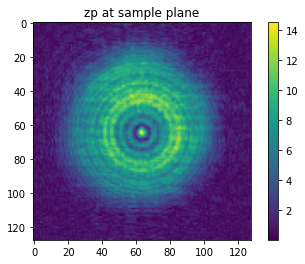

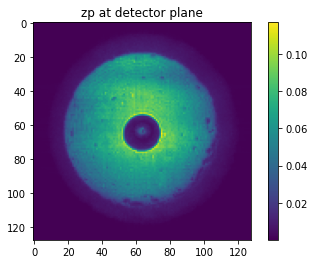

In [68]:


probe_defocus = np.load(r'Ptycho_CDI/S315465/t2_mask/recon_data/recon_315465_t2_mask_probe.npy')
probe_defocus = probe_defocus[0] / np.sqrt(3)



plt.figure()
plt.imshow(np.abs(probe_defocus))
plt.title('zp at sample plane')
plt.colorbar()


ft_probe = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(probe_defocus))) / np.prod(probe_defocus.shape)
plt.figure()
plt.imshow(np.abs(ft_probe))
plt.colorbar()
plt.title('zp at detector plane')




## Generate the obj with the central ptychogrpahy data

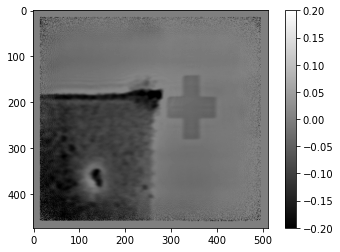

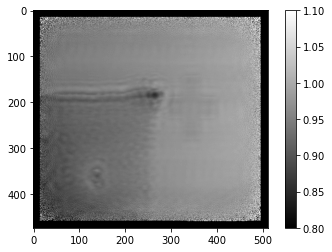

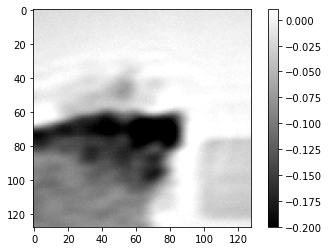

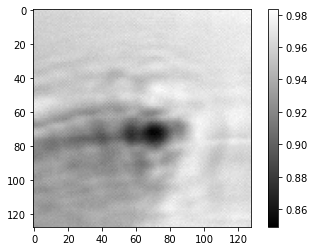

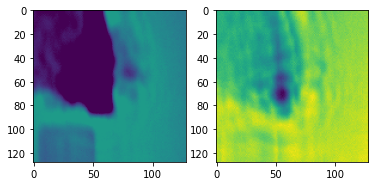

In [69]:
%matplotlib inline
# %matplotlib qt
pha = io.imread(r'Ptycho_CDI/S315465/t2_mask/recon_tif/recon_315465_t2_mask_object_pha0.tif')
amp = io.imread(r'Ptycho_CDI/S315465/t2_mask/recon_tif/recon_315465_t2_mask_object_amp0.tif')

plt.figure()
# plt.imshow(pha, cmap='gray')
plt.imshow(pha, cmap='gray', vmin=-0.2, vmax=0.2)
plt.colorbar()
plt.figure()
plt.imshow(amp, cmap='gray')
plt.colorbar()

# shift_x = -40
# shift_y = 10
# cy, cx = pha.shape[0]//2 - shift_y, pha.shape[1]//2 - shift_x

cx, cy = 228+30, 251-65-10
# cx, cy = np.shape(pha)[1]//2, np.shape(pha)[0]//2

pha = pha[cy-64:cy+64, cx-64:cx+64]

# amp = amp * np.sqrt(20)
# amp = amp[cy-64:cy+64, cx-64:cx+64] + 0.25
amp = amp[cy-64:cy+64, cx-64:cx+64]
# amp += 0.25


plt.figure()
plt.imshow(pha, cmap='gray')
plt.colorbar()
plt.figure()
plt.imshow(amp, cmap='gray')
plt.colorbar()


obj_real = amp * np.exp(1j * pha)
obj_real = np.rot90(obj_real, k=-1)

plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(np.angle(obj_real), vmin=-0.1, vmax=0.1)
plt.subplot(1, 2, 2)
plt.imshow(np.abs(obj_real))


## Use the obj to simualte the diffraction pattern

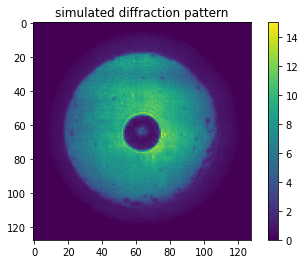

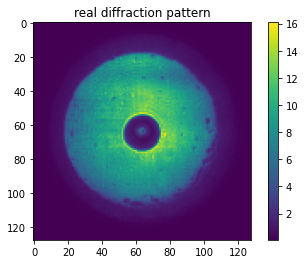

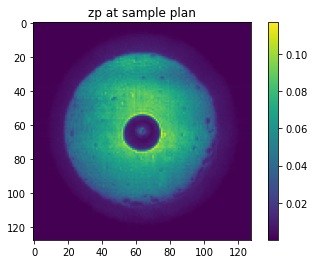

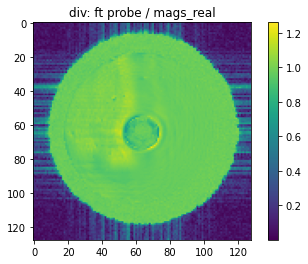

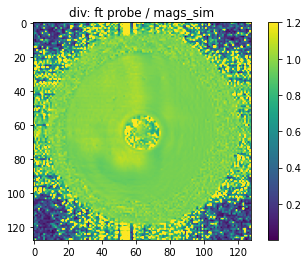

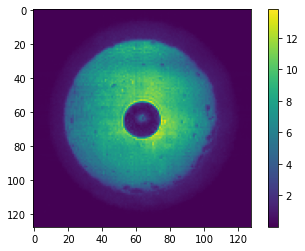

In [ ]:
# obj, probe_defocus
%matplotlib inline
F_OP = np.fft.fftn(obj_real * probe_defocus) / np.sqrt(np.prod(obj_real.shape))
mags_sim = np.abs(F_OP)
mags_sim = np.fft.fftshift(mags_sim)
plt.figure()
plt.imshow(mags_sim, vmin=0, vmax=15)
plt.title('simulated diffraction pattern')
# plt.imshow(mags_sim)
plt.colorbar()

# read the real diffraction pattern
mags_real = io.imread(r'eiger2_image_315464.tiff')
# mags_real = mags_real[0]
mags_real = average_every_k(mags_real, k=160)  # average every 20 frames
mags_real = mags_real[0]
# mags_real = np.mean(mags_real, axis=0)  # average over slices
# s0 = 11
# s1 = -2#8
# mags_real = mags_real[np.shape(mags_real)[0]//2 - 64 - s0 : np.shape(mags_real)[0]//2 + 64 - s0, np.shape(mags_real)[1]//2 - 64 - s1 : np.shape(mags_real)[1]//2 + 64 - s1]
mags_real = np.fliplr(mags_real.T)
mags_real = np.sqrt(mags_real)
mags_real, _, _ = crop_magnitude_to_probe_xcorr_skimage(mags_real, np.abs(ft_probe))
plt.figure()
plt.imshow(mags_real)
plt.title('real diffraction pattern')
plt.colorbar()


plt.figure()
plt.imshow(np.abs(ft_probe))
plt.colorbar()
plt.title('zp at sample plan')

# %matplotlib qt
plt.figure()
plt.imshow((np.abs(ft_probe)/np.max(np.abs(ft_probe))) / (mags_real/np.max(np.abs(mags_real))))
# plt.imshow((mags_real/np.max(np.abs(mags_real))) / (np.abs(ft_probe)/np.max(np.abs(ft_probe))), vmax=1.2)

plt.colorbar()
plt.title('div: ft probe / mags_real')

# plt.figure()
# # plt.imshow(np.abs(ft_probe)/np.max(np.abs(ft_probe)) - mags_real/np.max(mags_real))
# plt.imshow((np.abs(mags_sim)/np.max(np.abs(mags_sim))) / (mags_real/np.max(np.abs(mags_real))))
# plt.colorbar()
# plt.title('diff: mags_sim & mags_real')

plt.figure()
plt.imshow((np.abs(ft_probe)/np.max(np.abs(ft_probe))) / (mags_sim/np.max(np.abs(mags_sim))), vmax=1.2)
# plt.imshow((mags_sim/np.max(np.abs(mags_sim))) / (np.abs(ft_probe)/np.max(np.abs(ft_probe))), vmax=1.2)
plt.colorbar()
plt.title('div: ft probe / mags_sim')

F_OP = np.fft.fftn(obj_real * probe_defocus) / np.sqrt(np.prod(obj_real.shape))
F_OP = np.fft.fftshift(F_OP)
plt.figure()
plt.imshow(np.abs(F_OP))
plt.colorbar()



# Mask generation

Text(0.5, 1.0, 'initial phase')

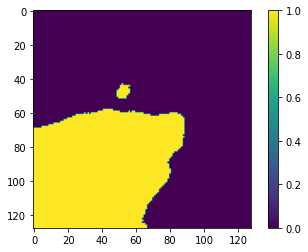

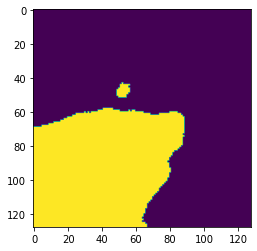

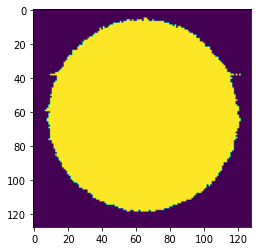

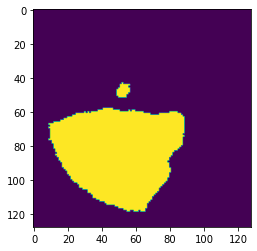

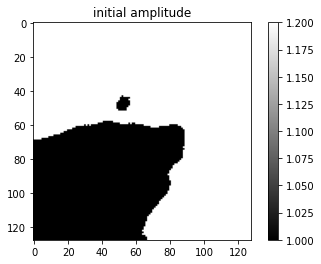

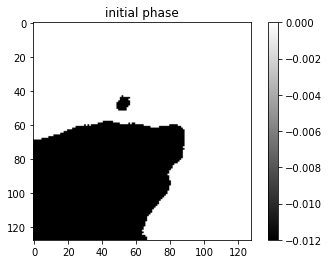

In [71]:
%matplotlib inline
from scipy import ndimage
from skimage.morphology import remove_small_objects

Smask = pha < -0.06
# Smask = ndimage.binary_dilation(Smask, iterations=10)
# Smask = remove_small_objects(Smask, min_size=1000)
plt.figure()
plt.imshow(Smask)
plt.colorbar()

# Pmask = (np.abs(ft_probe)/np.max(np.abs(ft_probe))) / (mags_real/np.max(np.abs(mags_real)))
# Pmask = Pmask > 0.8
# Pmask = binary_fill_holes(Pmask)
# io.imsave('Pmask.tiff', Pmask)

Pmask = io.imread('Pmask.tiff').astype(bool)
combined_mask = Smask & Pmask
plt.figure()
plt.imshow(Smask)

plt.figure()
plt.imshow(Pmask)

plt.figure()
plt.imshow(combined_mask)

pha_ini = np.ones_like(Smask, dtype=float)
pha_ini[~Smask] = 0
pha_ini[Smask] = -0.012

amp_ini = np.ones_like(Smask, dtype=float)
amp_ini[~Smask] = 1.2 #0.865
amp_ini[Smask] = 1.0 #0.82

ini = amp_ini * np.exp(1j * pha_ini)
plt.figure()
plt.imshow(np.abs(ini), cmap='gray')
plt.colorbar()
plt.title('initial amplitude')

plt.figure()
plt.imshow(np.angle(ini), cmap='gray')
plt.colorbar()
plt.title('initial phase')


## Phase retrieval - 1

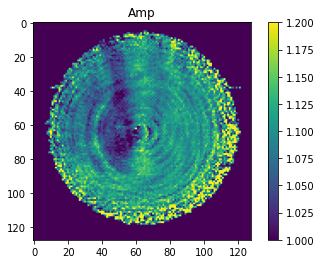

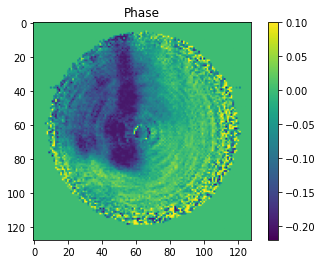

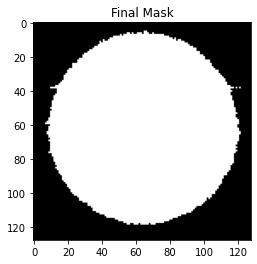

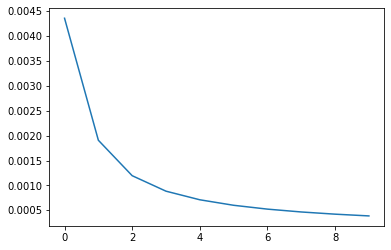

In [72]:
%matplotlib inline
# %matplotlib qt
# O = amp_ini*np.exp(1j*pha_ini) # 1+T_contrast
# O = Smask.copy()
O = obj_real.copy()  # initial guess
# O = Pmask.copy()  # initial guess

# mask = combined_mask.copy()
# mask = np.zeros_like(Smask, dtype=bool)
mask = Pmask.copy()
# mask = Smask.copy()
bkg_value = 1. * np.exp(1j*(0))
probe_known = probe_defocus.copy() * 1.0
O_sum = []
# bkg_value = 1
mse = []
epoch = 10
for i in range(epoch):
    esw = np.fft.fftshift(np.fft.fftn(O * probe_known)) / np.sqrt(np.prod(O.shape))
    # esw = fresnel_forward_1fft(O * probe_defocus, 12, 2.05, 75e-6)
    # esw = propagate(O * probe_defocus, 12, 2.05e6, 30e-3, 30e-3)
    
    esw_prime = mags_real*np.exp(1j*np.angle(esw))
    
    esw_back = np.fft.ifftn(np.fft.ifftshift(esw_prime)) * np.sqrt(np.prod(O.shape))
    # esw_back = fresnel_forward_1fft(esw_prime, 12, -2.05, 75e-6)
    # esw_back = propagate(esw_prime, 12, -2.05e6, 30e-3, 30e-3)
    
    
    O_prime = esw_back * np.conj(probe_known) / (np.abs(probe_known)**2 + 1e-6)

    
    O_prime = threshold_object(O_prime, amp_min=1, amp_max=1.25, pha_min=-0.2, pha_max=0.1)
    
    T_contrast = O - bkg_value
    T_contrast_prime = O_prime - bkg_value
    if i < 100:
        T_contrast = HIO_T_ERoutside(T_contrast, T_contrast_prime, mask, beta=0.7)
    else:
        T_contrast = _HIOupdate_contrast2(T_contrast, T_contrast_prime, mask, beta=0.5) # beta 0.5...
    O = T_contrast + bkg_value
    
    O = threshold_object(O, amp_min=1.00, amp_max=1.25, pha_min=-0.3, pha_max=0.1)
    # if i>0.8*epoch:
    #     O_sum.append(O)
    
    # O = er_update(O_prime, mask)
    mse.append(np.mean((np.abs(fftc(O*probe_defocus)) - mags_real)**2))
    # mse.append(np.mean((np.abs(np.fft.fftshift(np.fft.fftn(O*probe_defocus)))/np.prod(O.shape) - mags_sim)**2))
    
    if i % 10 == 0:
        bkg_value = np.mean(O[~mask])

 

plt.figure()
plt.imshow(np.abs(O), vmin=1, vmax=1.2)
plt.title('Amp')
# plt.imshow(np.abs(real_space_guess))
plt.colorbar()

plt.figure()
plt.imshow(np.angle(O), vmin=-0.22, vmax=0.1)
plt.title('Phase')
# plt.imshow(np.angle(new_real_space))
plt.colorbar()

# plt.figure()
# plt.imshow(np.angle(np.mean(O_sum, axis=0)), vmin=-0.1, vmax=0.1)
# plt.colorbar()


# plt.figure()
# plt.imshow(np.angle(np.mean(O_sum, axis=0)) - np.angle(O), vmin=-0.1, vmax=0.1)
# plt.colorbar()

plt.figure()
plt.imshow(mask, cmap='gray')
plt.title('Final Mask')


plt.figure()
plt.plot(mse)
# plt.plot(mse)


plt.show()


## Difference Map (in test)

In [ ]:
eps = 1e-6
beta = 0.9  # DM beta typically ~0.7–1.0

# Use your current definitions
O = obj_real.copy()
mask = Pmask.copy()
probe_known = probe_defocus.copy()

bkg_value = 1.2 * np.exp(1j*(-0.012))
mse = []

norm = np.sqrt(np.prod(O.shape))

def P_M(O_in):
    """Modulus projection (data constraint) mapped back to object using known probe."""
    esw = np.fft.fftshift(np.fft.fftn(O_in * probe_known)) / norm
    esw_prime = mags_real * np.exp(1j * np.angle(esw))
    esw_back = np.fft.ifftn(np.fft.ifftshift(esw_prime)) * norm
    O_out = esw_back * np.conj(probe_known) / (np.abs(probe_known)**2 + eps)
    return O_out

def P_S(O_in, bkg):
    """Support/object projection: outside -> background, inside -> thresholded object."""
    O_out = O_in.copy()

    # enforce outside-support/background
    O_out[~mask] = bkg

    # enforce inside-support constraints (your thresholds)
    O_out[mask] = threshold_object(
        O_out[mask],
        amp_min=1.00, amp_max=1.25,
        pha_min=-0.1, pha_max=0.1
    )
    return O_out

for i in range(2):
    # Projections
    PM_O = P_M(O)
    PS_O = P_S(O, bkg_value)

    # Difference-map auxiliary maps
    fS = (1 + 1/beta) * PS_O - (1/beta) * O
    fM = (1 + 1/beta) * PM_O - (1/beta) * O

    # DM update
    PM_fS = P_M(fS)
    PS_fM = P_S(fM, bkg_value)

    O = O + beta * (PM_fS - PS_fM)

    # (Optional) enforce mild object constraint again (sometimes helps keep things bounded)
    O = P_S(O, bkg_value)

    # Update background periodically (use current estimate outside support)
    if i % 10 == 0:
        bkg_value = np.mean(O[~mask])

    # Error metric (use the SAME normalization convention)
    esw_chk = np.fft.fftshift(np.fft.fftn(O * probe_known)) / norm
    mse.append(np.mean((np.abs(esw_chk) - mags_real)**2))

In [ ]:
%matplotlib inline
plt.figure()
plt.imshow(np.abs(O), vmin=0.6, vmax=1.2)
plt.title('Amp')
# plt.imshow(np.abs(real_space_guess))
plt.colorbar()

plt.figure()
plt.imshow(np.angle(O), vmin=-0.1, vmax=0.1)
plt.title('Phase')
# plt.imshow(np.angle(new_real_space))
plt.colorbar()
plt.show()
# %matplotlib inline
